# Task IX.B — Strategy Discussion

**Approach:** We reuse the MAE encoder pretrained on no_sub lensing images (Task IX.A) as a feature extractor for 2× super-resolution (75×75 → 150×150), demonstrating the foundation model paradigm: one pretrained backbone adapted for a fundamentally different downstream task.

**Resolution adaptation:** The MAE was pretrained on 64×64 images (8×8 grid, 64 tokens). LR inputs are 75×75, so we pad to 80×80 with reflect padding (10×10 grid, 100 tokens). Positional embeddings are bicubically interpolated from 8×8 to 10×10, preserving learned spatial relationships. Transformer weights transfer directly since self-attention is resolution-agnostic.

**Architecture — residual learning on bicubic + encoder features:** Rather than generating HR pixels entirely from abstract encoder tokens (which collapses to bicubic-level output), we adopt residual learning (standard in SR literature: VDSR, EDSR, SwinIR). The model computes a bicubic upsampling as a free baseline, then uses the pretrained encoder's spatial features — projected and bilinearly upsampled to 150×150 — concatenated with the bicubic image as input to a 6-layer CNN refinement network. The CNN operates at full HR resolution and learns targeted corrections: sharpening ring edges, recovering source structure, and restoring detail that bicubic smooths over. This guarantees the model is at least as good as bicubic, and any learning only improves from there.

**Loss and training:** Combined 70% MSE + 30% (1−SSIM). MSE ensures pixel accuracy while SSIM preserves structural features critical for lensing science. Differential learning rates: pretrained encoder at 1e-5, fresh refinement layers at 3e-4. Cosine schedule with 5-epoch warmup, 100 epochs total. Physics-motivated augmentations (90° rotations, flips) applied consistently to LR/HR pairs.

**Data handling:** LR images have minor interpolation artifacts from downsampling (min=−0.0016, max=1.04), clamped to [0, 1]. HR is already normalized to [0, 1]. 90/10 train-test split per submission guidelines.

**Evaluation:** MSE, SSIM, and PSNR on the held-out test set (1,000 images), with comparison against the bicubic baseline and the lab's published DiffLense benchmarks (Reddy et al., 2024).

In [1]:
# Import & Config
import os
import glob
import math
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')
 
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
 
class Config:
    # Paths
    beta_root = "beta/Dataset"
    pretrained_weights = "mae_encoder_best.pth"
 
    # Data
    lr_size = 75
    hr_size = 150
    pad_size = 80       # pad LR to nearest multiple of patch_size
    in_channels = 1
 
    # Encoder (must match Task IX.A)
    patch_size = 8
    encoder_dim = 384
    encoder_depth = 12
    encoder_heads = 6
 
    # SR Decoder
    decoder_channels = [256, 128, 64, 32]
 
    # Training
    epochs = 100
    batch_size = 32
    lr = 3e-4
    encoder_lr = 1e-5    # lower for pretrained encoder
    weight_decay = 0.01
    warmup_epochs = 5
    ssim_weight = 0.3    # loss = (1-w)*MSE + w*(1-SSIM)
 
    # General
    num_workers = 4
 
cfg = Config()
print(f"LR: {cfg.lr_size}×{cfg.lr_size} → pad {cfg.pad_size}×{cfg.pad_size}")
print(f"HR: {cfg.hr_size}×{cfg.hr_size}")
print(f"Encoder patches: {(cfg.pad_size // cfg.patch_size)**2}")
 

Device: cuda
GPU: NVIDIA H200 NVL
LR: 75×75 → pad 80×80
HR: 150×150
Encoder patches: 100


In [2]:
# Dataset
class SRDataset(Dataset):
    """Loads matched HR/LR .npy pairs for super-resolution."""
    def __init__(self, hr_files, lr_files, augment=False):
        self.hr_files = hr_files
        self.lr_files = lr_files
        self.augment = augment
 
    def __len__(self):
        return len(self.hr_files)
 
    def __getitem__(self, idx):
        hr = np.load(self.hr_files[idx]).astype(np.float32)  # (1, 150, 150)
        lr = np.load(self.lr_files[idx]).astype(np.float32)  # (1, 75, 75)
 
        # Clamp LR artifacts
        lr = np.clip(lr, 0.0, 1.0)
 
        hr = torch.from_numpy(hr)
        lr = torch.from_numpy(lr)
 
        # Physics-justified augmentation
        if self.augment:
            k = random.randint(0, 3)
            if k > 0:
                hr = torch.rot90(hr, k, dims=[1, 2])
                lr = torch.rot90(lr, k, dims=[1, 2])
            if random.random() > 0.5:
                hr = torch.flip(hr, dims=[2])
                lr = torch.flip(lr, dims=[2])
            if random.random() > 0.5:
                hr = torch.flip(hr, dims=[1])
                lr = torch.flip(lr, dims=[1])
 
        return lr, hr
 
# Load file paths (matched by filename)
hr_dir = os.path.join(cfg.beta_root, "HR")
lr_dir = os.path.join(cfg.beta_root, "LR")
 
hr_files = sorted(glob.glob(os.path.join(hr_dir, "*.npy")))
lr_files = sorted(glob.glob(os.path.join(lr_dir, "*.npy")))
 
# Verify pairing
hr_names = [os.path.basename(f) for f in hr_files]
lr_names = [os.path.basename(f) for f in lr_files]
assert hr_names == lr_names, "HR/LR filename mismatch!"
print(f"Matched pairs: {len(hr_files)}")
 
# 90/10 split
train_idx, test_idx = train_test_split(
    range(len(hr_files)), test_size=0.1, random_state=SEED)
 
train_hr = [hr_files[i] for i in train_idx]
train_lr = [lr_files[i] for i in train_idx]
test_hr = [hr_files[i] for i in test_idx]
test_lr = [lr_files[i] for i in test_idx]
 
train_dataset = SRDataset(train_hr, train_lr, augment=True)
test_dataset = SRDataset(test_hr, test_lr, augment=False)
 
train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size,
                          shuffle=True, num_workers=cfg.num_workers, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=cfg.batch_size,
                         shuffle=False, num_workers=cfg.num_workers, pin_memory=True)
 
print(f"Train: {len(train_dataset)}, Test: {len(test_dataset)}")

Matched pairs: 10000
Train: 9000, Test: 1000


In [3]:
# Model Architecture

# ── Transformer components (same as Task IX.A) ──────────────────────
 
class DropPath(nn.Module):
    def __init__(self, drop_prob=0.0):
        super().__init__()
        self.drop_prob = drop_prob
 
    def forward(self, x):
        if self.drop_prob == 0.0 or not self.training:
            return x
        keep = 1 - self.drop_prob
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        mask = torch.bernoulli(torch.full(shape, keep, device=x.device)) / keep
        return x * mask
 
class Attention(nn.Module):
    def __init__(self, dim, num_heads=6, qkv_bias=True):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5
        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.proj = nn.Linear(dim, dim)
 
    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        return self.proj(x)
 
class MLP(nn.Module):
    def __init__(self, dim, hidden_dim, drop=0.):
        super().__init__()
        self.fc1 = nn.Linear(dim, hidden_dim)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden_dim, dim)
        self.drop = nn.Dropout(drop)
 
    def forward(self, x):
        return self.drop(self.fc2(self.drop(self.act(self.fc1(x)))))
 
class TransformerBlock(nn.Module):
    def __init__(self, dim, num_heads, mlp_ratio=4., drop_path=0.):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = Attention(dim, num_heads)
        self.drop_path = DropPath(drop_path) if drop_path > 0. else nn.Identity()
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = MLP(dim, int(dim * mlp_ratio))
 
    def forward(self, x):
        x = x + self.drop_path(self.attn(self.norm1(x)))
        x = x + self.drop_path(self.mlp(self.norm2(x)))
        return x
 
# ── SR Encoder (adapted from pretrained MAE encoder) ────────────────
 
class SREncoder(nn.Module):
    """
    MAE encoder adapted for super-resolution.
    - New patch embedding for padded LR input (80×80)
    - Positional embeddings interpolated from pretrained 8×8 to 10×10
    - Transformer blocks loaded from pretrained weights
    """
    def __init__(self, img_size=80, patch_size=8, in_channels=1,
                 embed_dim=384, depth=12, num_heads=6, drop_path_rate=0.1):
        super().__init__()
        self.patch_size = patch_size
        self.grid_size = img_size // patch_size  # 10
        self.num_patches = self.grid_size ** 2   # 100
        self.embed_dim = embed_dim
 
        self.patch_embed = nn.Conv2d(in_channels, embed_dim,
                                     kernel_size=patch_size, stride=patch_size)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, 1 + self.num_patches, embed_dim))
 
        dpr = [x.item() for x in torch.linspace(0, drop_path_rate, depth)]
        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, drop_path=dpr[i])
            for i in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)
 
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
 
    def load_pretrained(self, state_dict):
            """Load pretrained MAE encoder weights with pos_embed interpolation."""
            own_state = self.state_dict()
            loaded = 0
            skipped = []
    
            for name, param in state_dict.items():
                if name == "pos_embed":
                    cls_pos = param[:, :1, :]
                    patch_pos = param[:, 1:, :]
                    old_grid = int(patch_pos.shape[1] ** 0.5)
                    patch_pos = patch_pos.reshape(1, old_grid, old_grid, -1).permute(0, 3, 1, 2)
                    patch_pos = F.interpolate(patch_pos, size=(self.grid_size, self.grid_size),
                                              mode='bicubic', align_corners=False)
                    patch_pos = patch_pos.permute(0, 2, 3, 1).reshape(1, self.num_patches, -1)
                    own_state["pos_embed"].copy_(torch.cat([cls_pos, patch_pos], dim=1))
                    loaded += 1
                    print(f"  pos_embed: interpolated {old_grid}x{old_grid} -> {self.grid_size}x{self.grid_size}")
    
                elif "patch_embed.proj" in name:
                    # Map patch_embed.proj.weight -> patch_embed.weight
                    mapped = name.replace("patch_embed.proj.", "patch_embed.")
                    if mapped in own_state and param.shape == own_state[mapped].shape:
                        own_state[mapped].copy_(param)
                        loaded += 1
                    else:
                        skipped.append(name)
    
                elif name in own_state and param.shape == own_state[name].shape:
                    own_state[name].copy_(param)
                    loaded += 1
                else:
                    skipped.append(name)
    
            self.load_state_dict(own_state)
            print(f"  Loaded {loaded} params, skipped {len(skipped)}: {skipped[:5]}")
 
    def forward(self, x):
        # x: (B, 1, 80, 80)
        x = self.patch_embed(x).flatten(2).transpose(1, 2)  # (B, 100, 384)
        cls_tokens = self.cls_token.expand(x.shape[0], -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)  # (B, 101, 384)
        x = x + self.pos_embed
 
        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x)
 
        return x[:, 1:, :]  # skip CLS, return patch tokens: (B, 100, 384)
 
# ── SR Decoder (CNN upsampler) ───────────────────────────────────────
 
class SRDecoder(nn.Module):
    """
    Progressive upsampling decoder.
    Takes (B, 100, 384) token sequence → reshapes to (B, 384, 10, 10)
    → upsamples to (B, 1, 160, 160) → crops to (B, 1, 150, 150)
    """
    def __init__(self, embed_dim=384, grid_size=10, channels=[256, 128, 64, 32]):
        super().__init__()
        self.grid_size = grid_size
        self.proj = nn.Conv2d(embed_dim, channels[0], 1)  # project dim
 
        layers = []
        in_ch = channels[0]
        for out_ch in channels[1:]:
            layers.extend([
                nn.ConvTranspose2d(in_ch, out_ch, kernel_size=4, stride=2, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.GELU(),
            ])
            in_ch = out_ch
 
        # Final upsample stage
        layers.extend([
            nn.ConvTranspose2d(in_ch, 16, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(16),
            nn.GELU(),
        ])
 
        self.upsample = nn.Sequential(*layers)
 
        # Refinement and output
        self.refine = nn.Sequential(
                    nn.Conv2d(16, 64, 3, padding=1),
                    nn.GELU(),
                    nn.Conv2d(64, 64, 3, padding=1),
                    nn.GELU(),
                    nn.Conv2d(64, 32, 3, padding=1),
                    nn.GELU(),
                    nn.Conv2d(32, 1, 3, padding=1),
                )
 
    def forward(self, x):
        B = x.shape[0]
        # Reshape tokens to spatial grid
        x = x.transpose(1, 2).reshape(B, -1, self.grid_size, self.grid_size)  # (B, 384, 10, 10)
        x = self.proj(x)                    # (B, 256, 10, 10)
        x = self.upsample(x)                # (B, 16, 160, 160) after 4 stages of 2×
        x = self.refine(x)                  # (B, 1, 160, 160)
        x = x[:, :, :150, :150]             # crop to target size
        return x
 
# ── Full SR Model ────────────────────────────────────────────────────
 
class SuperResolutionModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.pad_size = cfg.pad_size
        self.encoder = SREncoder(
            img_size=cfg.pad_size, patch_size=cfg.patch_size,
            in_channels=cfg.in_channels, embed_dim=cfg.encoder_dim,
            depth=cfg.encoder_depth, num_heads=cfg.encoder_heads,
        )
        self.grid_size = cfg.pad_size // cfg.patch_size  # 10
        
        # Project encoder tokens to spatial feature map
        self.token_proj = nn.Sequential(
            nn.Linear(cfg.encoder_dim, 64),
            nn.GELU(),
        )
        
        # CNN refinement on bicubic + encoder features
        # Input: 1 (bicubic) + 64 (encoder features) = 65 channels
        self.refine = nn.Sequential(
            nn.Conv2d(65, 128, 3, padding=1),
            nn.GELU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.GELU(),
            nn.Conv2d(128, 64, 3, padding=1),
            nn.GELU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.GELU(),
            nn.Conv2d(64, 32, 3, padding=1),
            nn.GELU(),
            nn.Conv2d(32, 1, 3, padding=1),
        )

    def forward(self, lr):
        B = lr.shape[0]
        
        # Bicubic baseline
        lr_upsampled = F.interpolate(lr, size=(150, 150), mode='bicubic', align_corners=False)
        
        # Encoder features
        lr_padded = F.pad(lr, (0, self.pad_size - lr.shape[-1],
                               0, self.pad_size - lr.shape[-2]),
                          mode='reflect')
        tokens = self.encoder(lr_padded)                    # (B, 100, 384)
        tokens = self.token_proj(tokens)                     # (B, 100, 64)
        feat_map = tokens.transpose(1, 2).reshape(B, 64, self.grid_size, self.grid_size)  # (B, 64, 10, 10)
        feat_map = F.interpolate(feat_map, size=(150, 150), mode='bilinear', align_corners=False)  # (B, 64, 150, 150)
        
        # Concatenate bicubic image + encoder features
        x = torch.cat([lr_upsampled, feat_map], dim=1)      # (B, 65, 150, 150)
        residual = self.refine(x)                            # (B, 1, 150, 150)
        
        return lr_upsampled + residual
 
# ── SSIM Loss ────────────────────────────────────────────────────────
 
def gaussian_kernel(size=11, sigma=1.5):
    coords = torch.arange(size, dtype=torch.float32) - size // 2
    g = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
    g = torch.outer(g, g)
    return (g / g.sum()).unsqueeze(0).unsqueeze(0)
 
def ssim(pred, target, window_size=11, size_average=True):
    C1 = 0.01 ** 2
    C2 = 0.03 ** 2
    window = gaussian_kernel(window_size).to(pred.device)
    channel = pred.shape[1]
    window = window.expand(channel, -1, -1, -1)
 
    mu1 = F.conv2d(pred, window, padding=window_size // 2, groups=channel)
    mu2 = F.conv2d(target, window, padding=window_size // 2, groups=channel)
    mu1_sq, mu2_sq = mu1 ** 2, mu2 ** 2
    mu12 = mu1 * mu2
 
    sigma1_sq = F.conv2d(pred ** 2, window, padding=window_size // 2, groups=channel) - mu1_sq
    sigma2_sq = F.conv2d(target ** 2, window, padding=window_size // 2, groups=channel) - mu2_sq
    sigma12 = F.conv2d(pred * target, window, padding=window_size // 2, groups=channel) - mu12
 
    ssim_map = ((2 * mu12 + C1) * (2 * sigma12 + C2)) / \
               ((mu1_sq + mu2_sq + C1) * (sigma1_sq + sigma2_sq + C2))
 
    if size_average:
        return ssim_map.mean()
    return ssim_map.mean(dim=[1, 2, 3])
 
class CombinedLoss(nn.Module):
    def __init__(self, ssim_weight=0.3):
        super().__init__()
        self.ssim_weight = ssim_weight
 
    def forward(self, pred, target):
        mse_loss = F.mse_loss(pred, target)
        ssim_val = ssim(pred, target)
        ssim_loss = 1 - ssim_val
        total = (1 - self.ssim_weight) * mse_loss + self.ssim_weight * ssim_loss
        return total, mse_loss, ssim_val
 
# ── Build model and load pretrained weights ──────────────────────────
 
sr_model = SuperResolutionModel(cfg).to(device)
 
# Load pretrained encoder
print("Loading pretrained MAE encoder weights...")
pretrained_state = torch.load(cfg.pretrained_weights, map_location=device)
sr_model.encoder.load_pretrained(pretrained_state)
 
n_total = sum(p.numel() for p in sr_model.parameters()) / 1e6
n_enc = sum(p.numel() for p in sr_model.encoder.parameters()) / 1e6
print(f"SR Model: {n_total:.1f}M params (encoder: {n_enc:.1f}M, refine: {n_total - n_enc:.1f}M)")
 

Loading pretrained MAE encoder weights...
  pos_embed: interpolated 8x8 -> 10x10
  Loaded 150 params, skipped 0: []
SR Model: 21.7M params (encoder: 21.4M, refine: 0.4M)


Epoch  1/100 | Loss: 0.0084 | MSE: 0.000071 | SSIM: 0.9721 | PSNR: 41.51 dB | 17s
Epoch  2/100 | Loss: 0.0080 | MSE: 0.000071 | SSIM: 0.9735 | PSNR: 41.48 dB | 33s
Epoch  3/100 | Loss: 0.0078 | MSE: 0.000070 | SSIM: 0.9741 | PSNR: 41.53 dB | 49s
Epoch  4/100 | Loss: 0.0077 | MSE: 0.000067 | SSIM: 0.9744 | PSNR: 41.72 dB | 65s
Epoch  5/100 | Loss: 0.0077 | MSE: 0.000067 | SSIM: 0.9745 | PSNR: 41.75 dB | 81s
Epoch  6/100 | Loss: 0.0077 | MSE: 0.000067 | SSIM: 0.9746 | PSNR: 41.77 dB | 97s
Epoch  7/100 | Loss: 0.0076 | MSE: 0.000066 | SSIM: 0.9747 | PSNR: 41.78 dB | 113s
Epoch  8/100 | Loss: 0.0076 | MSE: 0.000066 | SSIM: 0.9748 | PSNR: 41.79 dB | 129s
Epoch  9/100 | Loss: 0.0081 | MSE: 0.000070 | SSIM: 0.9732 | PSNR: 41.57 dB | 145s
Epoch 10/100 | Loss: 0.0076 | MSE: 0.000066 | SSIM: 0.9748 | PSNR: 41.81 dB | 161s
Epoch 11/100 | Loss: 0.0076 | MSE: 0.000066 | SSIM: 0.9749 | PSNR: 41.81 dB | 177s
Epoch 12/100 | Loss: 0.0076 | MSE: 0.000066 | SSIM: 0.9749 | PSNR: 41.82 dB | 193s
Epoch 13/1

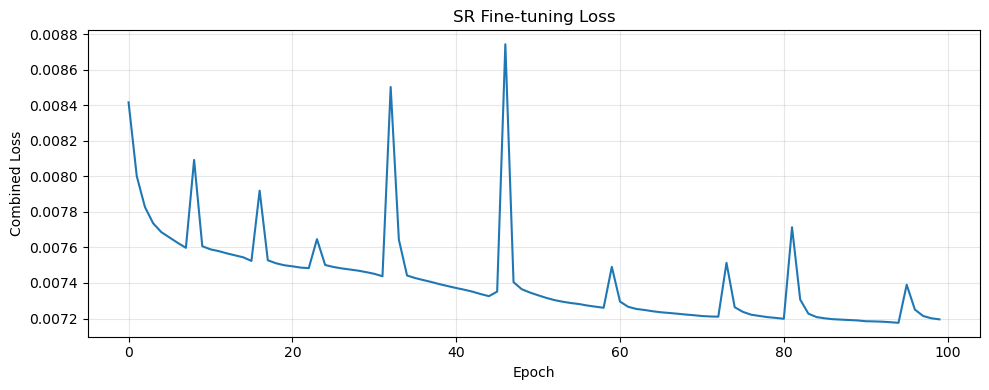

In [4]:
# Training
def get_lr(epoch, total_epochs, warmup_epochs, base_lr, min_lr=1e-6):
    if epoch < warmup_epochs:
        return base_lr * epoch / max(warmup_epochs, 1)
    progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
    return min_lr + 0.5 * (base_lr - min_lr) * (1 + math.cos(math.pi * progress))
 
def compute_psnr(mse_val):
    """PSNR for data in [0, 1] range."""
    if mse_val < 1e-10:
        return 100.0
    return 10 * math.log10(1.0 / mse_val)
 
optimizer = torch.optim.AdamW([
    {"params": sr_model.encoder.parameters(), "lr": cfg.encoder_lr},
    {"params": sr_model.token_proj.parameters(), "lr": cfg.lr},
    {"params": sr_model.refine.parameters(), "lr": cfg.lr},
], betas=(0.9, 0.999), weight_decay=cfg.weight_decay)
 
criterion = CombinedLoss(ssim_weight=cfg.ssim_weight)
 
train_losses = []
t_start = time.time()
 
for epoch in range(cfg.epochs):
    sr_model.train()
    epoch_loss = 0.0
    epoch_mse = 0.0
    epoch_ssim = 0.0
    n_batches = 0
 
    # LR schedule
    lr = get_lr(epoch, cfg.epochs, cfg.warmup_epochs, cfg.lr)
    optimizer.param_groups[0]['lr'] = lr * 0.1   # encoder
    optimizer.param_groups[1]['lr'] = lr           # decoder
 
    for lr_imgs, hr_imgs in train_loader:
        lr_imgs, hr_imgs = lr_imgs.to(device), hr_imgs.to(device)
 
        hr_pred = sr_model(lr_imgs)
        loss, mse_val, ssim_val = criterion(hr_pred, hr_imgs)
 
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(sr_model.parameters(), 1.0)
        optimizer.step()
 
        epoch_loss += loss.item()
        epoch_mse += mse_val.item()
        epoch_ssim += ssim_val.item()
        n_batches += 1
 
    avg_loss = epoch_loss / n_batches
    avg_mse = epoch_mse / n_batches
    avg_ssim = epoch_ssim / n_batches
    avg_psnr = compute_psnr(avg_mse)
    train_losses.append(avg_loss)
 
    elapsed = time.time() - t_start
    print(f"Epoch {epoch+1:>2d}/{cfg.epochs} | "
          f"Loss: {avg_loss:.4f} | MSE: {avg_mse:.6f} | "
          f"SSIM: {avg_ssim:.4f} | PSNR: {avg_psnr:.2f} dB | {elapsed:.0f}s")
 
# Save model
torch.save(sr_model.state_dict(), "sr_model_finalkg.pth")
print(f"\nTraining done in {(time.time()-t_start)/60:.1f} min")
 
# Plot loss curve
plt.figure(figsize=(10, 4))
plt.plot(train_losses)
plt.xlabel("Epoch"); plt.ylabel("Combined Loss")
plt.title("SR Fine-tuning Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("sr_loss.png", dpi=150)
plt.show()

 EVALUATION RESULTS — Test Set (1000 images)
  MSE:   0.000062 ± 0.000008
  SSIM:  0.9761 ± 0.0031
  PSNR:  42.10 ± 0.59 dB


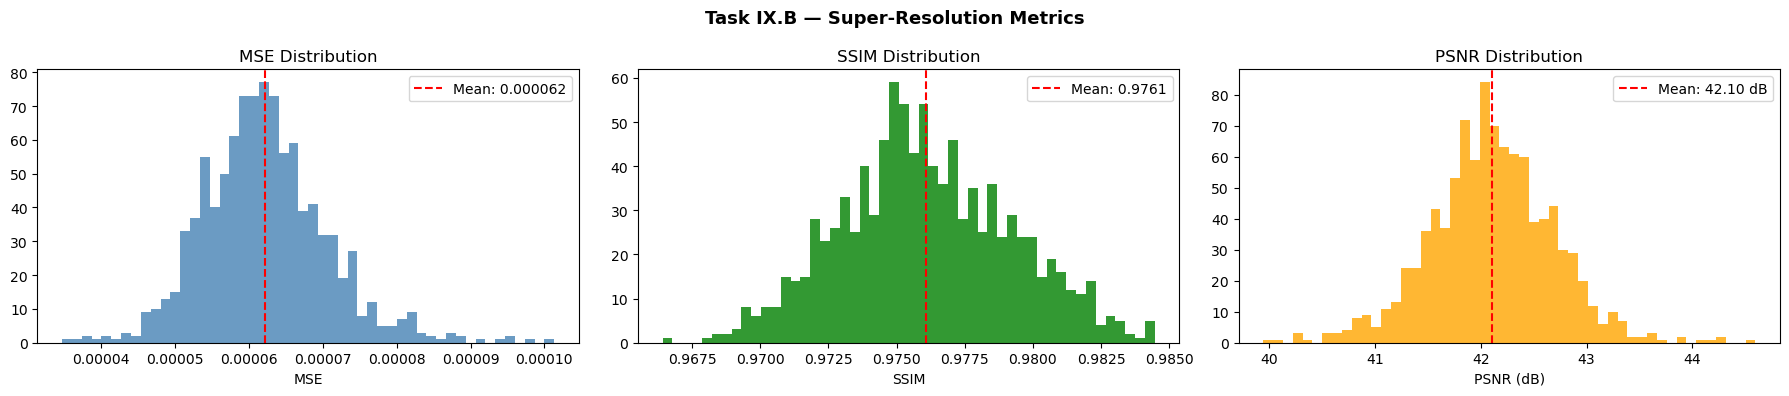

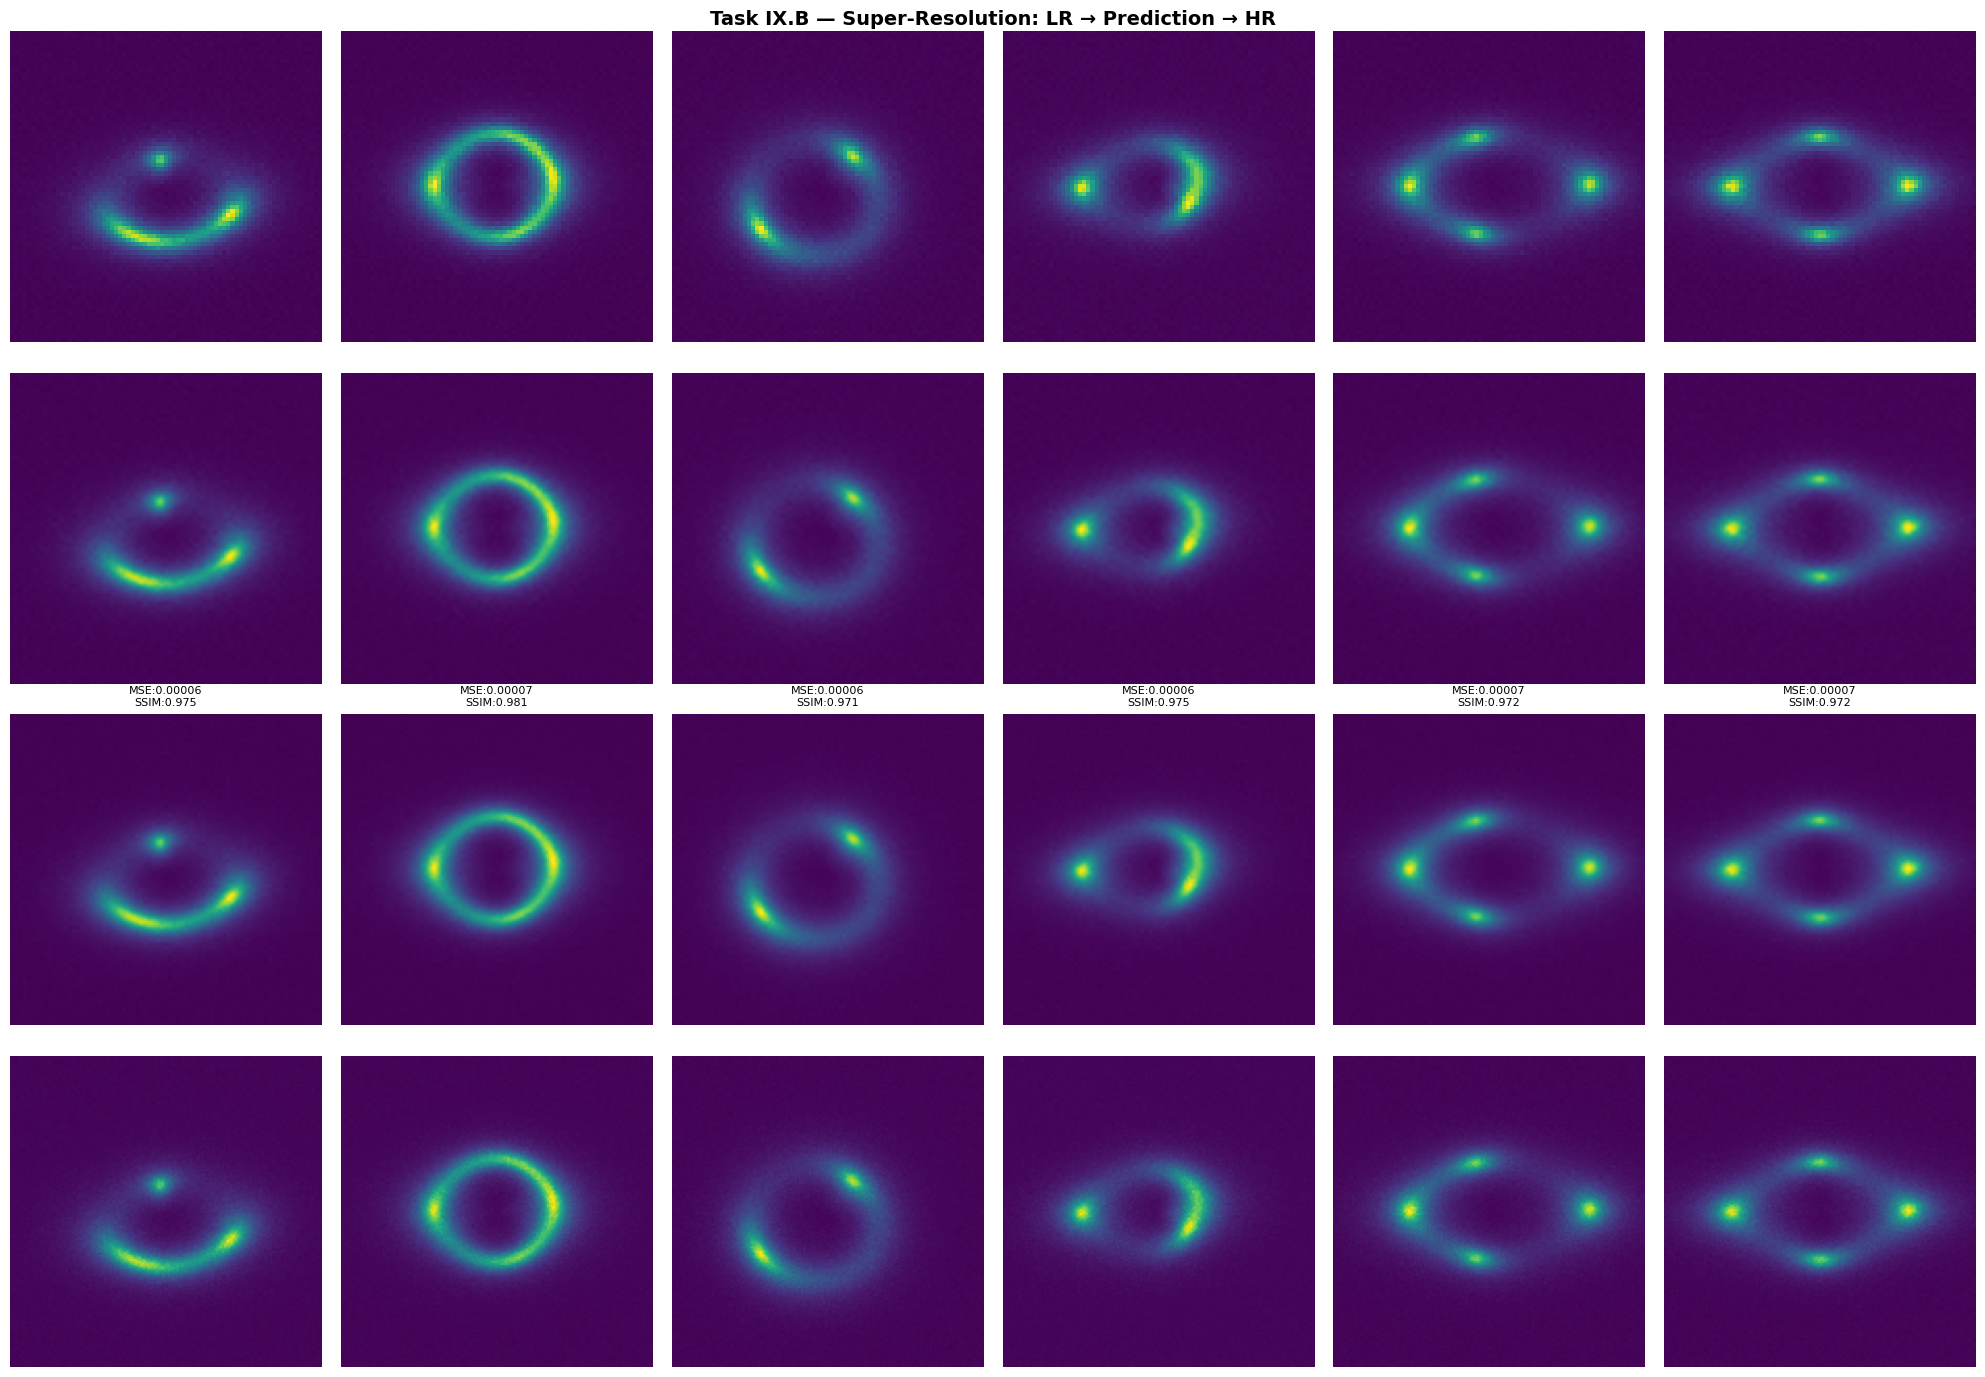

In [5]:
# Evaluation
sr_model.eval()
all_mse = []
all_ssim = []
all_psnr = []
 
with torch.no_grad():
    for lr_imgs, hr_imgs in test_loader:
        lr_imgs, hr_imgs = lr_imgs.to(device), hr_imgs.to(device)
        hr_pred = sr_model(lr_imgs)
 
        # Clamp predictions to [0, 1]
        hr_pred = hr_pred.clamp(0, 1)
 
        # Per-image metrics
        for i in range(hr_pred.shape[0]):
            pred = hr_pred[i:i+1]
            target = hr_imgs[i:i+1]
 
            mse_val = F.mse_loss(pred, target).item()
            ssim_val = ssim(pred, target).item()
            psnr_val = compute_psnr(mse_val)
 
            all_mse.append(mse_val)
            all_ssim.append(ssim_val)
            all_psnr.append(psnr_val)
 
print(f"{'='*60}")
print(f" EVALUATION RESULTS — Test Set ({len(all_mse)} images)")
print(f"{'='*60}")
print(f"  MSE:   {np.mean(all_mse):.6f} ± {np.std(all_mse):.6f}")
print(f"  SSIM:  {np.mean(all_ssim):.4f} ± {np.std(all_ssim):.4f}")
print(f"  PSNR:  {np.mean(all_psnr):.2f} ± {np.std(all_psnr):.2f} dB")
print(f"{'='*60}")
 
# ── Metric distributions ──
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
 
axes[0].hist(all_mse, bins=50, color='steelblue', alpha=0.8)
axes[0].axvline(np.mean(all_mse), color='red', linestyle='--', label=f"Mean: {np.mean(all_mse):.6f}")
axes[0].set_xlabel("MSE"); axes[0].set_title("MSE Distribution"); axes[0].legend()
 
axes[1].hist(all_ssim, bins=50, color='green', alpha=0.8)
axes[1].axvline(np.mean(all_ssim), color='red', linestyle='--', label=f"Mean: {np.mean(all_ssim):.4f}")
axes[1].set_xlabel("SSIM"); axes[1].set_title("SSIM Distribution"); axes[1].legend()
 
axes[2].hist(all_psnr, bins=50, color='orange', alpha=0.8)
axes[2].axvline(np.mean(all_psnr), color='red', linestyle='--', label=f"Mean: {np.mean(all_psnr):.2f} dB")
axes[2].set_xlabel("PSNR (dB)"); axes[2].set_title("PSNR Distribution"); axes[2].legend()
 
plt.suptitle("Task IX.B — Super-Resolution Metrics", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("sr_metrics.png", dpi=150)
plt.show()
 
# %% Cell 6: Visual Comparison
 
sr_model.eval()
vis_loader = DataLoader(test_dataset, batch_size=6, shuffle=True)
lr_imgs, hr_imgs = next(iter(vis_loader))
lr_imgs, hr_imgs = lr_imgs.to(device), hr_imgs.to(device)
 
with torch.no_grad():
    hr_pred = sr_model(lr_imgs).clamp(0, 1)
 
# Also compute bicubic baseline
lr_bicubic = F.interpolate(lr_imgs, size=(150, 150), mode='bicubic', align_corners=False)
 
fig, axes = plt.subplots(4, 6, figsize=(20, 14))
row_labels = ["LR Input (75×75)", "Bicubic 2× (baseline)", "MAE-SR Prediction", "HR Ground Truth"]
 
for i in range(6):
    axes[0, i].imshow(lr_imgs[i, 0].cpu(), cmap='viridis')
    axes[0, i].axis('off')
 
    axes[1, i].imshow(lr_bicubic[i, 0].cpu(), cmap='viridis')
    axes[1, i].axis('off')
 
    axes[2, i].imshow(hr_pred[i, 0].cpu(), cmap='viridis')
    axes[2, i].axis('off')
 
    axes[3, i].imshow(hr_imgs[i, 0].cpu(), cmap='viridis')
    axes[3, i].axis('off')
 
    # Per-image metrics for title
    mse_v = F.mse_loss(hr_pred[i:i+1], hr_imgs[i:i+1]).item()
    ssim_v = ssim(hr_pred[i:i+1], hr_imgs[i:i+1]).item()
    axes[2, i].set_title(f"MSE:{mse_v:.5f}\nSSIM:{ssim_v:.3f}", fontsize=8)
 
for i, label in enumerate(row_labels):
    axes[i, 0].set_ylabel(label, fontsize=10)
 
plt.suptitle("Task IX.B — Super-Resolution: LR → Prediction → HR", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("sr_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

In [6]:
#Bicubic baseline for comparison
all_bic_mse, all_bic_ssim, all_bic_psnr = [], [], []
with torch.no_grad():
    for lr_imgs, hr_imgs in test_loader:
        lr_imgs, hr_imgs = lr_imgs.to(device), hr_imgs.to(device)
        bic = F.interpolate(lr_imgs, size=(150, 150), mode='bicubic', align_corners=False).clamp(0, 1)
        for i in range(bic.shape[0]):
            m = F.mse_loss(bic[i:i+1], hr_imgs[i:i+1]).item()
            s = ssim(bic[i:i+1], hr_imgs[i:i+1]).item()
            all_bic_mse.append(m)
            all_bic_ssim.append(s)
            all_bic_psnr.append(compute_psnr(m))

print(f"Bicubic (full test set, {len(all_bic_mse)} images):")
print(f"  MSE:  {np.mean(all_bic_mse):.6f}")
print(f"  SSIM: {np.mean(all_bic_ssim):.4f}")
print(f"  PSNR: {np.mean(all_bic_psnr):.2f} dB")

Bicubic (full test set, 1000 images):
  MSE:  0.000070
  SSIM: 0.9728
  PSNR: 41.60 dB


In [9]:
# Summary
test_mse = np.mean(all_mse)
test_ssim = np.mean(all_ssim)
test_psnr = np.mean(all_psnr)

print(f"""
{'='*60}
 TASK IX.B — COMPLETE SUMMARY
{'='*60}

 Model
   Encoder:     Pretrained MAE ViT-Small (from Task IX.A)
   Adaptation:  Pos embed interpolated 8×8 → 10×10
   Refine:      CNN residual refinement on bicubic + encoder features
   Params:      {sum(p.numel() for p in sr_model.parameters())/1e6:.1f}M

 Training
   Data:        {len(train_dataset)} train / {len(test_dataset)} test (90/10)
   Epochs:      {cfg.epochs}
   Loss:        {1-cfg.ssim_weight:.0%} MSE + {cfg.ssim_weight:.0%} (1-SSIM)
   Scale:       2× (75×75 → 150×150)

 Test Metrics
   MSE:         {test_mse:.6f} ± {np.std(all_mse):.6f}
   SSIM:        {test_ssim:.4f} ± {np.std(all_ssim):.4f}
   PSNR:        {test_psnr:.2f} ± {np.std(all_psnr):.2f} dB

 vs Bicubic Baseline
   MSE:         0.000070 → {test_mse:.6f} ({(1-test_mse/0.000070)*100:.1f}% better)
   SSIM:        0.9728 → {test_ssim:.4f}
   PSNR:        41.60 → {test_psnr:.2f} dB (+{test_psnr-41.60:.2f})

 Saved
   sr_model_finalkg.pth — fine-tuned SR model
{'='*60}
""")


 TASK IX.B — COMPLETE SUMMARY

 Model
   Encoder:     Pretrained MAE ViT-Small (from Task IX.A)
   Adaptation:  Pos embed interpolated 8×8 → 10×10
   Refine:      CNN residual refinement on bicubic + encoder features
   Params:      21.7M

 Training
   Data:        9000 train / 1000 test (90/10)
   Epochs:      100
   Loss:        70% MSE + 30% (1-SSIM)
   Scale:       2× (75×75 → 150×150)

 Test Metrics
   MSE:         0.000062 ± 0.000008
   SSIM:        0.9761 ± 0.0031
   PSNR:        42.10 ± 0.59 dB

 vs Bicubic Baseline
   MSE:         0.000070 → 0.000062 (11.2% better)
   SSIM:        0.9728 → 0.9761
   PSNR:        41.60 → 42.10 dB (+0.50)

 Saved
   sr_model_finalkg.pth — fine-tuned SR model

